# Individual performances

This notebook highlights the individual performances of each models on each datasets.

Results are not presented in the paper but can be useful to have some better understanding of some results.

In [1]:
import numpy as np
import pandas as pd

from utils import load_nested_results

all_results = load_nested_results("results")

In [2]:
from sklearn.metrics import average_precision_score

datasets_names = list(all_results.keys())
n_fold = len(all_results[datasets_names[0]]["ground_truth"].keys())

all_res_summary = {}

for dataset in datasets_names:
    results = all_results[dataset]

    all_res = []
    for fold in range(n_fold):
        y_true = results["ground_truth"][fold]

        if len(np.unique(y_true)) == 1:
            continue

        fold_res = []

        for model_name in list(results.keys() - {"ground_truth"}):
            y_scores = results[model_name][fold]["scores"]
            auc = average_precision_score(y_true, y_scores)
            fold_res.append(auc)

        all_res.append(fold_res)
    all_res = np.array(all_res)
    mean_res = np.mean(all_res, axis=0)
    std_res = np.std(all_res, axis=0)

    all_res_summary[dataset] = [
        f"{mean_res[i]:.2f} ± {std_res[i]:.2f}" for i in range(len(mean_res))
    ]

In [3]:
df = pd.DataFrame.from_dict(
    all_res_summary,
    orient="index",
    columns=list(results.keys() - {"ground_truth"}),
)
df

,GMM,MCD,COPOD,AutoEncoder,LODA,PCA,DeepSVDD,CBLOF,ECOD,HBOS,IForest,KNN,LOF,OCSVM
2_annthyroid,0.16 ± 0.02,0.51 ± 0.02,0.18 ± 0.01,0.24 ± 0.02,0.11 ± 0.04,0.21 ± 0.03,0.21 ± 0.05,0.18 ± 0.03,0.29 ± 0.04,0.25 ± 0.02,0.30 ± 0.04,0.24 ± 0.02,0.19 ± 0.02,0.20 ± 0.03
4_breastw,0.92 ± 0.04,0.97 ± 0.02,0.99 ± 0.01,0.90 ± 0.05,0.98 ± 0.01,0.96 ± 0.02,0.93 ± 0.06,0.88 ± 0.06,0.99 ± 0.01,0.96 ± 0.02,0.97 ± 0.02,0.92 ± 0.04,0.33 ± 0.04,0.93 ± 0.04
14_glass,0.11 ± 0.05,0.13 ± 0.05,0.11 ± 0.06,0.13 ± 0.08,0.07 ± 0.04,0.09 ± 0.05,0.11 ± 0.08,0.13 ± 0.03,0.10 ± 0.06,0.11 ± 0.05,0.11 ± 0.05,0.15 ± 0.04,0.11 ± 0.05,0.10 ± 0.07
15_Hepatitis,0.52 ± 0.23,0.55 ± 0.23,0.59 ± 0.23,0.58 ± 0.21,0.37 ± 0.19,0.60 ± 0.27,0.36 ± 0.12,0.57 ± 0.26,0.51 ± 0.19,0.47 ± 0.22,0.54 ± 0.22,0.55 ± 0.24,0.52 ± 0.18,0.57 ± 0.21
21_Lymphography,0.78 ± 0.27,0.77 ± 0.23,1.00 ± 0.00,0.97 ± 0.07,0.77 ± 0.20,0.97 ± 0.07,0.85 ± 0.20,0.97 ± 0.07,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.97 ± 0.07,0.97 ± 0.07,0.92 ± 0.17
23_mammography,0.20 ± 0.04,0.07 ± 0.03,0.45 ± 0.06,0.14 ± 0.05,0.22 ± 0.10,0.23 ± 0.04,0.15 ± 0.07,0.16 ± 0.05,0.46 ± 0.06,0.15 ± 0.05,0.20 ± 0.04,0.18 ± 0.05,0.10 ± 0.02,0.21 ± 0.04
27_PageBlocks,0.56 ± 0.06,0.62 ± 0.04,0.38 ± 0.04,0.51 ± 0.05,0.44 ± 0.11,0.52 ± 0.05,0.49 ± 0.06,0.56 ± 0.06,0.53 ± 0.06,0.32 ± 0.04,0.47 ± 0.04,0.54 ± 0.07,0.36 ± 0.03,0.54 ± 0.06
29_Pima,0.51 ± 0.03,0.50 ± 0.03,0.52 ± 0.05,0.50 ± 0.04,0.42 ± 0.06,0.50 ± 0.04,0.46 ± 0.04,0.49 ± 0.04,0.48 ± 0.04,0.55 ± 0.06,0.50 ± 0.05,0.52 ± 0.04,0.43 ± 0.04,0.48 ± 0.04
37_Stamps,0.41 ± 0.12,0.39 ± 0.11,0.65 ± 0.18,0.46 ± 0.20,0.51 ± 0.17,0.52 ± 0.14,0.54 ± 0.25,0.29 ± 0.07,0.51 ± 0.18,0.50 ± 0.08,0.50 ± 0.15,0.44 ± 0.15,0.28 ± 0.09,0.45 ± 0.15
38_thyroid,0.33 ± 0.09,0.72 ± 0.10,0.24 ± 0.07,0.40 ± 0.14,0.25 ± 0.09,0.43 ± 0.09,0.32 ± 0.16,0.33 ± 0.12,0.55 ± 0.11,0.56 ± 0.10,0.57 ± 0.14,0.38 ± 0.11,0.12 ± 0.03,0.41 ± 0.10


In [4]:
df.to_latex()

'\\begin{tabular}{lllllllllllllll}\n\\toprule\n & GMM & MCD & COPOD & AutoEncoder & LODA & PCA & DeepSVDD & CBLOF & ECOD & HBOS & IForest & KNN & LOF & OCSVM \\\\\n\\midrule\n2_annthyroid & 0.16 ± 0.02 & 0.51 ± 0.02 & 0.18 ± 0.01 & 0.24 ± 0.02 & 0.11 ± 0.04 & 0.21 ± 0.03 & 0.21 ± 0.05 & 0.18 ± 0.03 & 0.29 ± 0.04 & 0.25 ± 0.02 & 0.30 ± 0.04 & 0.24 ± 0.02 & 0.19 ± 0.02 & 0.20 ± 0.03 \\\\\n4_breastw & 0.92 ± 0.04 & 0.97 ± 0.02 & 0.99 ± 0.01 & 0.90 ± 0.05 & 0.98 ± 0.01 & 0.96 ± 0.02 & 0.93 ± 0.06 & 0.88 ± 0.06 & 0.99 ± 0.01 & 0.96 ± 0.02 & 0.97 ± 0.02 & 0.92 ± 0.04 & 0.33 ± 0.04 & 0.93 ± 0.04 \\\\\n14_glass & 0.11 ± 0.05 & 0.13 ± 0.05 & 0.11 ± 0.06 & 0.13 ± 0.08 & 0.07 ± 0.04 & 0.09 ± 0.05 & 0.11 ± 0.08 & 0.13 ± 0.03 & 0.10 ± 0.06 & 0.11 ± 0.05 & 0.11 ± 0.05 & 0.15 ± 0.04 & 0.11 ± 0.05 & 0.10 ± 0.07 \\\\\n15_Hepatitis & 0.52 ± 0.23 & 0.55 ± 0.23 & 0.59 ± 0.23 & 0.58 ± 0.21 & 0.37 ± 0.19 & 0.60 ± 0.27 & 0.36 ± 0.12 & 0.57 ± 0.26 & 0.51 ± 0.19 & 0.47 ± 0.22 & 0.54 ± 0.22 & 0.55 ± 0.24 & 0.52

In [5]:
df_numeric = df.map(lambda x: float(str(x).split("±")[0].strip()))
df_numeric.median(axis=1).round(2)

2_annthyroid       0.21
4_breastw          0.94
14_glass           0.11
15_Hepatitis       0.55
21_Lymphography    0.97
23_mammography     0.19
27_PageBlocks      0.52
29_Pima            0.50
37_Stamps          0.48
38_thyroid         0.39
39_vertebral       0.13
40_vowels          0.24
42_WBC             0.85
44_Wilt            0.04
45_wine            0.32
47_yeast           0.33
dtype: float64

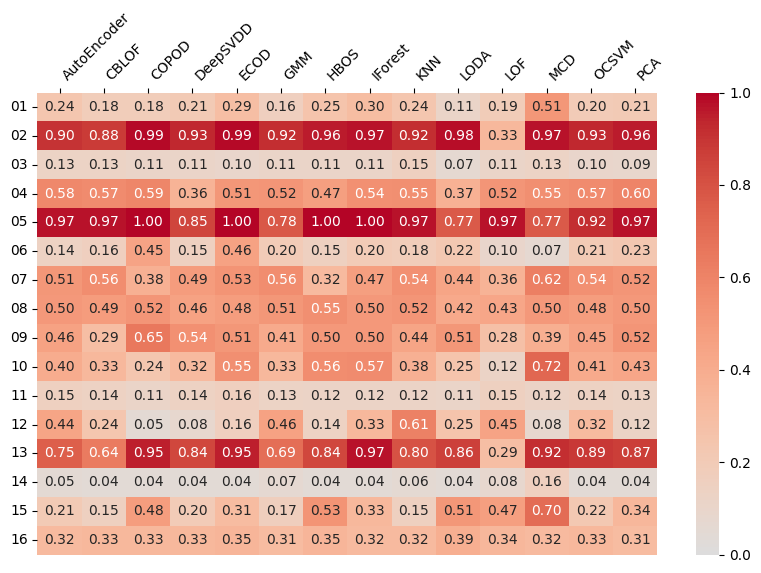

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sympy import rotations

map_names = {
    "2_annthyroid": "01",
    "4_breastw": "02",
    "14_glass": "03",
    "15_Hepatitis": "04",
    "21_Lymphography": "05",
    "23_mammography": "06",
    "27_PageBlocks": "07",
    "29_Pima": "08",
    "37_Stamps": "09",
    "38_thyroid": "10",
    "39_vertebral": "11",
    "40_vowels": "12",
    "42_WBC": "13",
    "44_Wilt": "14",
    "45_wine": "15",
    "47_yeast": "16",
}

df_numeric = df_numeric.rename(index=map_names)
df_numeric = df_numeric.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# sns.set_theme(style="whitegrid", font_scale=1)
sns.heatmap(
    df_numeric,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    ax=ax,
    vmin=0,
    vmax=1,
)


ax.xaxis.tick_top()
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)


# ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
plt.xticks(rotation=45, ha="left")

for spine in ax.spines.values():
    spine.set_visible(False)

# plt.tight_layout()
# plt.show()

fig.savefig("img/perf.eps", bbox_inches="tight", pad_inches=0.1, transparent=False)

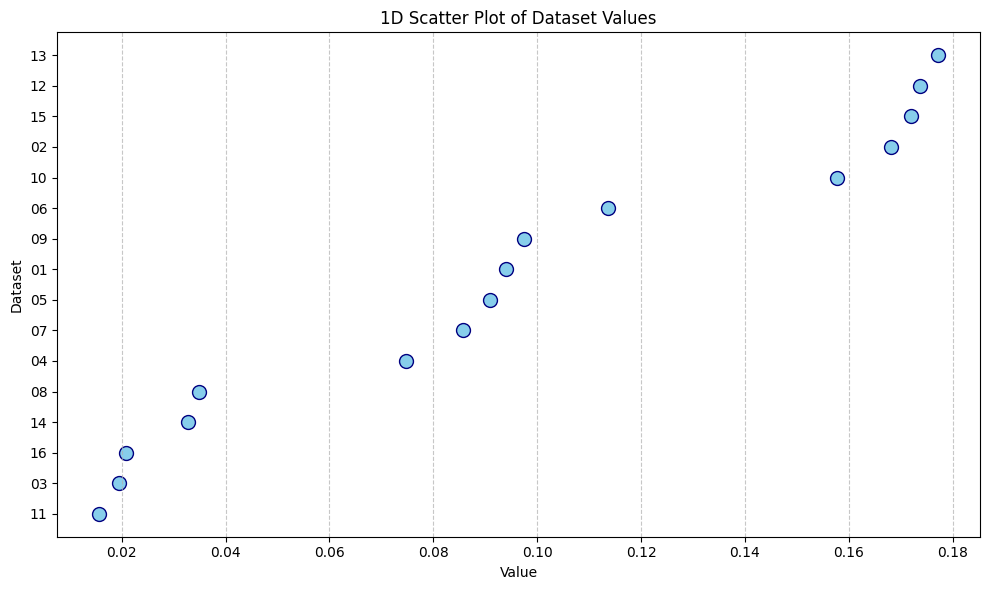

In [ ]:
df = pd.Series(df_numeric.std(axis=1)).sort_values()

plt.figure(figsize=(10, 6))
plt.scatter(df.values, df.index, color="skyblue", edgecolor="navy", s=100)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.xlabel("Value")
plt.ylabel("Dataset")
plt.title("1D Scatter Plot of Dataset Values")
plt.tight_layout()

# plt.savefig("img/scatter_plot.png")

In [8]:
df_numeric.median(axis=1)

01    0.210
02    0.945
03    0.110
04    0.545
05    0.970
06    0.190
07    0.515
08    0.500
09    0.480
10    0.390
11    0.130
12    0.245
13    0.850
14    0.040
15    0.320
16    0.330
dtype: float64